# Setup

In [48]:
import polars as pl 
import matplotlib.pyplot as plt
import os 
import importlib 
import seaborn as sns

# Set the font family to Arial
# https://g.co/gemini/share/3898a74b2d77
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial'] # Add Arial to the sans-serif list

plt.rcParams.update({
    'font.size': 20,
})

# Check if the environment variable in .env was actually set in the shell
print(f"PYTHONPATH: {os.environ.get('PYTHONPATH')}")

pl.Config.set_tbl_rows(10) 

PYTHONPATH: /scratch/ucgd/lustre-labs/quinlan/u6018199/tapestry-tools/src/tapestry_tools


polars.config.Config

# Read candidate imprinted loci 

In [49]:
from read_data import read_dataframe_from_bed

def read_imprinted_candidates(bed): 
    df = read_dataframe_from_bed(bed)
    # df = df.with_columns(
    #     pl.col("imprinted_samples").str.split(",")
    # )
    return df

DF_IMPRINTED_CANDIDATES = read_imprinted_candidates(
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidates.all-samples.bed'
)
DF_IMPRINTED_CANDIDATES

chrom,start,end,imprinted_samples,num_imprinted_samples,num_imprinted_samples_pat_meth,num_imprinted_samples_mat_meth,locus
str,i64,i64,str,i64,i64,i64,str
"""chr1""",68050000,68051000,"""NA12877:Mat,NA12878:Mat,NA1288…",19,1,18,"""chr1:68050000-68051000"""
"""chr1""",147078000,147079000,"""NA12878:Pat,NA12887:Mat,NA1287…",8,3,5,"""chr1:147078000-147079000"""
"""chr1""",205850000,205851000,"""NA12887:Mat,200084:Mat,200103:…",3,1,2,"""chr1:205850000-205851000"""
"""chr1""",247937000,247938000,"""NA12885:Pat,NA12879:Mat,200102…",3,2,1,"""chr1:247937000-247938000"""
"""chr2""",36183000,36184000,"""200084:Pat,200101:Pat,200103:P…",4,4,0,"""chr2:36183000-36184000"""
…,…,…,…,…,…,…,…
"""chrX""",151396000,151397000,"""200081:Mat""",1,0,1,"""chrX:151396000-151397000"""
"""chrX""",151397000,151398000,"""200081:Mat""",1,0,1,"""chrX:151397000-151398000"""
"""chrX""",154341000,154342000,"""200081:Mat""",1,0,1,"""chrX:154341000-154342000"""


# Read Akbari et al 2023 truth set

In [50]:
def read_truth_set_imprinted_loci(): 
    df = (
        pl
        .read_csv(
            'Akbari2023CellGenomics.csv', 
            separator=',',
            comment_prefix=None,
            has_header=True,
            null_values="NA"
        )
        .rename({ 
            'Chromosome': 'chrom',
            'Start': 'start',
            'End': 'end',
            'Methylated allele': 'methylated_allele',
            'Name': 'genes',
            'Study(Reference #)': 'study (reference #)',
            '# of individuals could be examined': 'num_samples_examined',
            '# of individuals with partial methylation': 'num_imprinted_samples',
            '% Individuals with partial methylation': 'percent_imprinted_samples',
            '# of tissues could be examined': 'num_tissues_examined',
            '# of tissues with partial methylation': 'num_imprinted_tissues',
            '% tissues with partial methylation': 'percent_imprinted_tissues'
        })
        .with_columns(
            (pl.col('end') - pl.col('start')).alias('length')
        )
    )
    return df.select(['chrom', 'start', 'end', 'length'] + df.columns[3:-1])

DF_IMPRINTED_TRUTH = read_truth_set_imprinted_loci()
DF_IMPRINTED_TRUTH

chrom,start,end,length,methylated_allele,genes,study (reference #),num_samples_examined,num_imprinted_samples,percent_imprinted_samples,num_tissues_examined,num_imprinted_tissues,percent_imprinted_tissues
str,i64,i64,i64,str,str,str,i64,i64,f64,i64,i64,f64
"""chr1""",11501432,11501606,174,"""Maternal""","""PTCHD2""","""Hernandez(31)""",82,20,24.39,25,7,28.0
"""chr1""",21292978,21293090,112,"""Maternal""","""ECE1;LOC100506801""","""Hernandez(31)""",64,0,0.0,27,6,22.22
"""chr1""",32471178,32471396,218,"""Maternal""","""ZBTB8B""","""Joshi(30)""",81,43,53.09,25,12,48.0
"""chr1""",39515809,39516076,267,"""Maternal""","""BMP8A""","""Akbari(32)""",22,1,4.55,23,6,26.09
"""chr1""",39558940,39560069,1129,"""Maternal""","""PPIEL,PABPC4""","""Akbari(32),Court(29),Hernandez…",86,2,2.33,28,3,10.71
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr9""",95312864,95313633,769,"""Maternal""","""FANCC,FANCC_Int1-DMR""","""Akbari(32),Hernandez(31)""",86,58,67.44,29,17,58.62
"""chr9""",97574899,97575448,549,"""Maternal""","""TMOD1""","""Akbari(32)""",82,29,35.37,27,4,14.81
"""chr9""",113088975,113090248,1273,"""Maternal""","""AL449105.5""","""Hernandez(31)""",84,6,7.14,28,5,17.86


# Compare candidate imprinted loci with Akbari et al 2023 truth set

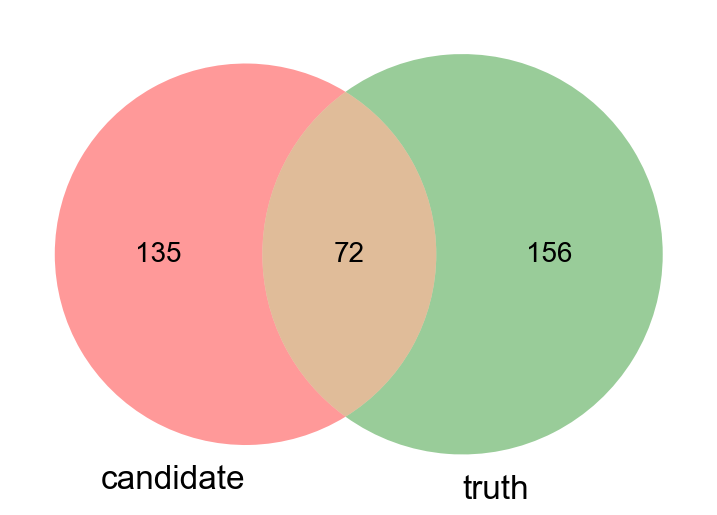

In [51]:
from find_unique_and_common_records import find_unique_and_common_records_with_venn_diagram 

DF_IMPRINTED_CANDIDATES_UNIQUE, DF_IMPRINTED_TRUTH_UNIQUE, DF_IMPRINTED_COMMON = find_unique_and_common_records_with_venn_diagram(
    DF_IMPRINTED_CANDIDATES, 
    DF_IMPRINTED_TRUTH, 
    min_overlap=100, 
    labels=('candidate', 'truth')
)

### Loci common to candidate and truth sets

In [52]:
METHYLATED_ALLELE_THRESHOLD = 0.25

def compute_consensus_methylated_allele(df):        
    return (
        df
        .with_columns(
            pl
            .when((pl.col("num_imprinted_samples_pat_meth") - pl.col("num_imprinted_samples_mat_meth"))/pl.col("num_imprinted_samples") > METHYLATED_ALLELE_THRESHOLD)
            .then(pl.lit("Paternal"))
            .when((pl.col("num_imprinted_samples_pat_meth") - pl.col("num_imprinted_samples_mat_meth"))/pl.col("num_imprinted_samples") < -METHYLATED_ALLELE_THRESHOLD)
            .then(pl.lit("Maternal"))
            .otherwise(pl.lit("Discordant"))
            .alias("consensus_methylated_allele")
        )        
    )

compute_consensus_methylated_allele(DF_IMPRINTED_COMMON).select([
    'chrom', 'start', 'end', 'num_imprinted_samples', 'num_imprinted_samples_pat_meth', 'num_imprinted_samples_mat_meth', 'consensus_methylated_allele',
    'chrom_2', 'start_2', 'end_2', 'length_2', 'methylated_allele_2',
    'overlap_len'
])

chrom,start,end,num_imprinted_samples,num_imprinted_samples_pat_meth,num_imprinted_samples_mat_meth,consensus_methylated_allele,chrom_2,start_2,end_2,length_2,methylated_allele_2,overlap_len
str,i64,i64,i64,i64,i64,str,str,i64,i64,i64,str,i64
"""chr1""",68050000,68051000,19,1,18,"""Maternal""","""chr1""",68046745,68052008,5263,"""Maternal""",1000
"""chr2""",206250000,206251000,11,11,0,"""Paternal""","""chr2""",206249709,206274051,24342,"""Paternal""",1000
"""chr2""",206251000,206252000,6,6,0,"""Paternal""","""chr2""",206249709,206274051,24342,"""Paternal""",1000
"""chr2""",206252000,206253000,2,2,0,"""Paternal""","""chr2""",206249709,206274051,24342,"""Paternal""",1000
"""chr2""",206256000,206257000,2,2,0,"""Paternal""","""chr2""",206249709,206274051,24342,"""Paternal""",1000
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20""",58855000,58856000,14,1,13,"""Maternal""","""chr20""",58850116,58856591,6475,"""Maternal""",1000
"""chr20""",58856000,58857000,15,1,14,"""Maternal""","""chr20""",58850116,58856591,6475,"""Maternal""",591
"""chr20""",58888000,58889000,17,1,16,"""Maternal""","""chr20""",58887966,58890443,2477,"""Maternal""",1000


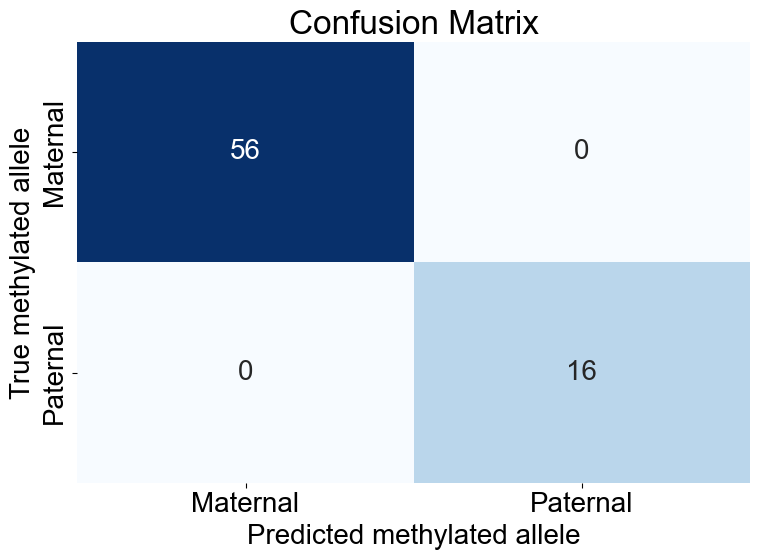

In [53]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(df): 
    df = compute_consensus_methylated_allele(df)

    y_true = df['methylated_allele_2']
    y_pred = df['consensus_methylated_allele']

    cm = confusion_matrix(y_true, y_pred)

    class_names = ['Maternal', 'Paternal']
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm, 
        annot=True,            # Show the numeric counts in the cells
        fmt='d',               # Use decimal integer format
        cmap='Blues',          # Color scheme
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar=False             # Remove the color bar for a cleaner look
    )

    plt.xlabel('Predicted methylated allele')
    plt.ylabel('True methylated allele')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(DF_IMPRINTED_COMMON)

In [54]:
from write_data import write_dataframe_to_bed

write_dataframe_to_bed(
    DF_IMPRINTED_COMMON, 
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-common.akbari.bed',
    source=globals()["__vsc_ipynb_file__"]
)

### Loci in truth-unique set

In [55]:
DF_IMPRINTED_TRUTH_UNIQUE 

chrom,start,end,length,methylated_allele,genes,study (reference #),num_samples_examined,num_imprinted_samples,percent_imprinted_samples,num_tissues_examined,num_imprinted_tissues,percent_imprinted_tissues,locus
str,i64,i64,i64,str,str,str,i64,i64,f64,i64,i64,f64,str
"""chr1""",11501432,11501606,174,"""Maternal""","""PTCHD2""","""Hernandez(31)""",82,20,24.39,25,7,28.0,"""chr1:11501432-11501606"""
"""chr1""",21292978,21293090,112,"""Maternal""","""ECE1;LOC100506801""","""Hernandez(31)""",64,0,0.0,27,6,22.22,"""chr1:21292978-21293090"""
"""chr1""",32471178,32471396,218,"""Maternal""","""ZBTB8B""","""Joshi(30)""",81,43,53.09,25,12,48.0,"""chr1:32471178-32471396"""
"""chr1""",39515809,39516076,267,"""Maternal""","""BMP8A""","""Akbari(32)""",22,1,4.55,23,6,26.09,"""chr1:39515809-39516076"""
"""chr1""",39558940,39560069,1129,"""Maternal""","""PPIEL,PABPC4""","""Akbari(32),Court(29),Hernandez…",86,2,2.33,28,3,10.71,"""chr1:39558940-39560069"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr21""",14063938,14064099,161,"""Maternal""","""LIPI""","""Joshi(30)""",82,8,9.76,25,6,24.0,"""chr21:14063938-14064099"""
"""chr21""",39385480,39386798,1318,"""Maternal""","""WRB""","""Akbari(32),Court(29),Hernandez…",83,34,40.96,28,12,42.86,"""chr21:39385480-39386798"""
"""chr21""",46661115,46661858,743,"""Maternal""","""PRMT2""","""Akbari(32),Zink(6)""",85,24,28.24,29,4,13.79,"""chr21:46661115-46661858"""


In [56]:
write_dataframe_to_bed(
    DF_IMPRINTED_TRUTH_UNIQUE, 
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-truth-unique.akbari.bed',
    source=globals()["__vsc_ipynb_file__"]
)

### Loci in candidate-unique set

In [57]:
DF_IMPRINTED_CANDIDATES_UNIQUE

chrom,start,end,imprinted_samples,num_imprinted_samples,num_imprinted_samples_pat_meth,num_imprinted_samples_mat_meth,locus
str,i64,i64,str,i64,i64,i64,str
"""chr1""",147078000,147079000,"""NA12878:Pat,NA12887:Mat,NA1287…",8,3,5,"""chr1:147078000-147079000"""
"""chr1""",205850000,205851000,"""NA12887:Mat,200084:Mat,200103:…",3,1,2,"""chr1:205850000-205851000"""
"""chr1""",247937000,247938000,"""NA12885:Pat,NA12879:Mat,200102…",3,2,1,"""chr1:247937000-247938000"""
"""chr2""",36183000,36184000,"""200084:Pat,200101:Pat,200103:P…",4,4,0,"""chr2:36183000-36184000"""
"""chr2""",87413000,87414000,"""200102:Mat""",1,0,1,"""chr2:87413000-87414000"""
…,…,…,…,…,…,…,…
"""chrX""",151396000,151397000,"""200081:Mat""",1,0,1,"""chrX:151396000-151397000"""
"""chrX""",151397000,151398000,"""200081:Mat""",1,0,1,"""chrX:151397000-151398000"""
"""chrX""",154341000,154342000,"""200081:Mat""",1,0,1,"""chrX:154341000-154342000"""


In [58]:
write_dataframe_to_bed(
    DF_IMPRINTED_CANDIDATES_UNIQUE, 
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidate-unique.akbari.bed',
    source=globals()["__vsc_ipynb_file__"]
)

# Inspect consistency of methylation on pat and mat haplotypes across samples 

### Compute methylation at loci in truth-unique set

```
compute-methylation-loci \
    --loci-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-truth-unique.akbari.bed \
    --sample-meth-beds /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/all-cpgs.all-samples.tsv \
    --loci-meth-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-truth-unique.akbari.meth.bed
```

### Visualize haplotype-specific methylation at a random subset of truth-unique loci

In [59]:
import get_sample_metadata
importlib.reload(get_sample_metadata)
from get_sample_metadata import get_sampleid_generation_gender_age_methylation

get_sampleid_generation_gender_age_methylation()

id,generation,gender,age_at_blood_draw,founder_phased_methylation
str,str,str,i64,str
"""NA12877""","""2nd""","""Male""",74,"""/scratch/ucgd/lustre-labs/quin…"
"""NA12878""","""2nd""","""Female""",73,"""/scratch/ucgd/lustre-labs/quin…"
"""NA12887""","""3rd""","""Female""",39,"""/scratch/ucgd/lustre-labs/quin…"
"""NA12885""","""3rd""","""Female""",43,"""/scratch/ucgd/lustre-labs/quin…"
"""NA12883""","""3rd""","""Male""",46,"""/scratch/ucgd/lustre-labs/quin…"
…,…,…,…,…
"""200102""","""4th""","""Male""",35,"""/scratch/ucgd/lustre-labs/quin…"
"""200103""","""4th""","""Female""",33,"""/scratch/ucgd/lustre-labs/quin…"
"""200104""","""4th""","""Female""",29,"""/scratch/ucgd/lustre-labs/quin…"


0.53 0.83 E G NA12877 chr21:39385480-39386798 Male 74
0.45 0.80 E K NA12887 chr21:39385480-39386798 Female 39
0.41 0.84 E I NA12885 chr21:39385480-39386798 Female 43
0.55 0.84 G I NA12883 chr21:39385480-39386798 Male 46
0.52 0.86 E K NA12886 chr21:39385480-39386798 Male 41
0.44 0.88 G K NA12884 chr21:39385480-39386798 Male 44
0.38 0.86 E I NA12882 chr21:39385480-39386798 Male 47
0.63 0.61 A K 200081 chr21:39385480-39386798 Female 50
0.56 0.83 A G 200082 chr21:39385480-39386798 Female 48
0.56 0.83 B G 200084 chr21:39385480-39386798 Male 46
0.38 0.86 A G 200085 chr21:39385480-39386798 Male 43
0.52 0.84 B G 200086 chr21:39385480-39386798 Female 41
0.49 0.88 K C 200101 chr21:39385480-39386798 Male 37
0.48 0.83 E D 200102 chr21:39385480-39386798 Male 35
0.56 0.84 K C 200103 chr21:39385480-39386798 Female 33
0.50 0.81 K C 200105 chr21:39385480-39386798 Male 26


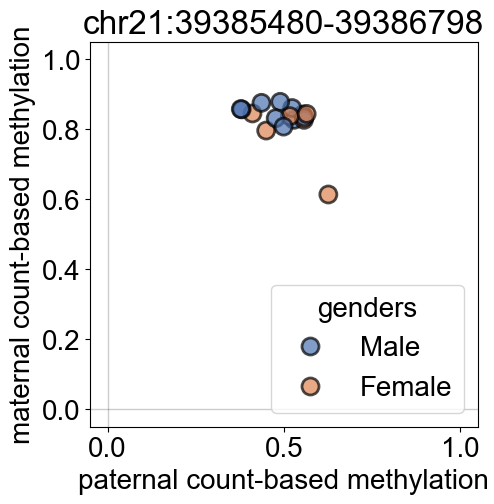

0.66 0.77 E G NA12877 chr8:140349118-140349831 Male 74
0.57 0.70 I K NA12878 chr8:140349118-140349831 Female 73
0.56 0.84 E I NA12887 chr8:140349118-140349831 Female 39
0.45 0.66 G I NA12885 chr8:140349118-140349831 Female 43
0.70 0.71 G K NA12883 chr8:140349118-140349831 Male 46
0.76 0.76 E K NA12881 chr8:140349118-140349831 Female 50
0.61 0.71 G K NA12879 chr8:140349118-140349831 Female 53
0.52 0.79 G K NA12884 chr8:140349118-140349831 Male 44
0.66 0.79 E K NA12882 chr8:140349118-140349831 Male 47
0.63 0.65 A G 200081 chr8:140349118-140349831 Female 50
0.72 0.76 B K 200084 chr8:140349118-140349831 Male 46
0.68 0.82 A G 200085 chr8:140349118-140349831 Male 43
0.72 0.83 B G 200086 chr8:140349118-140349831 Female 41
0.76 0.77 E C 200101 chr8:140349118-140349831 Male 37
0.70 0.79 I C 200102 chr8:140349118-140349831 Male 35
0.59 0.56 I D 200103 chr8:140349118-140349831 Female 33
0.59 0.82 I D 200104 chr8:140349118-140349831 Female 29
0.61 0.87 I C 200105 chr8:140349118-140349831 Male 26
0

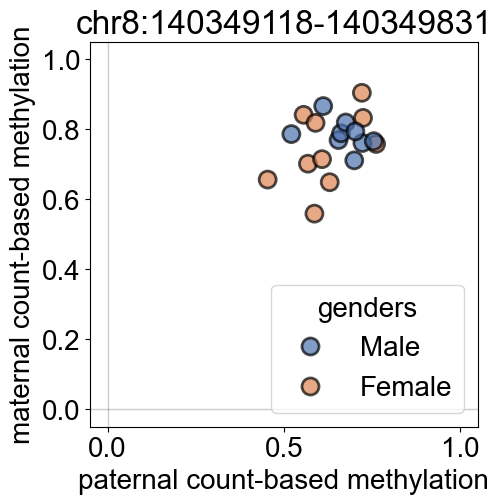

0.49 0.65 E G NA12877 chr20:59526001-59526478 Male 74
0.47 0.71 I K NA12878 chr20:59526001-59526478 Female 73
0.61 0.68 E I NA12887 chr20:59526001-59526478 Female 39
0.59 0.68 G K NA12885 chr20:59526001-59526478 Female 43
0.72 0.72 E K NA12883 chr20:59526001-59526478 Male 46
0.44 0.70 G I NA12881 chr20:59526001-59526478 Female 50
0.35 0.62 G I NA12879 chr20:59526001-59526478 Female 53
0.52 0.68 G K NA12884 chr20:59526001-59526478 Male 44
0.39 0.72 G I NA12882 chr20:59526001-59526478 Male 47
0.56 0.44 A G 200081 chr20:59526001-59526478 Female 50
0.63 0.63 A G 200082 chr20:59526001-59526478 Female 48
0.69 0.65 B G 200084 chr20:59526001-59526478 Male 46
0.63 0.74 B I 200086 chr20:59526001-59526478 Female 41
0.57 0.65 E D 200101 chr20:59526001-59526478 Male 37
0.62 0.58 I C 200102 chr20:59526001-59526478 Male 35
0.53 0.58 E C 200103 chr20:59526001-59526478 Female 33
0.60 0.63 E C 200105 chr20:59526001-59526478 Male 26
0.45 0.68 E D 200106 chr20:59526001-59526478 Female 24


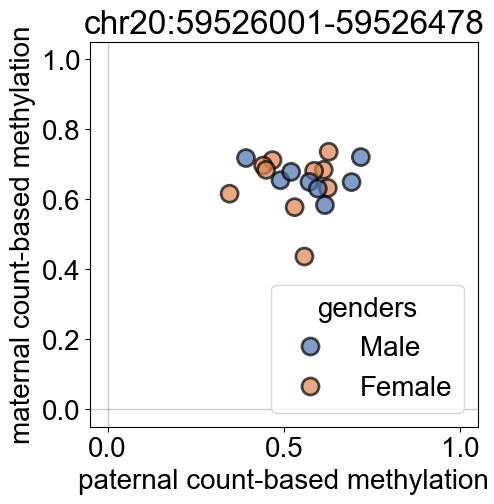

0.72 0.43 E G NA12877 chr15:24274859-24275806 Male 74
0.71 0.55 I K NA12878 chr15:24274859-24275806 Female 73
0.74 0.59 G I NA12887 chr15:24274859-24275806 Female 39
0.66 0.57 G I NA12885 chr15:24274859-24275806 Female 43
0.67 0.66 G I NA12883 chr15:24274859-24275806 Male 46
0.67 0.53 E I NA12881 chr15:24274859-24275806 Female 50
0.59 0.58 G K NA12879 chr15:24274859-24275806 Female 53
0.69 0.57 G K NA12886 chr15:24274859-24275806 Male 41
0.70 0.51 E I NA12884 chr15:24274859-24275806 Male 44
0.72 0.64 G I NA12882 chr15:24274859-24275806 Male 47
0.72 0.62 B G 200081 chr15:24274859-24275806 Female 50
0.69 0.56 B G 200082 chr15:24274859-24275806 Female 48
0.75 0.61 A K 200084 chr15:24274859-24275806 Male 46
0.71 0.58 A K 200085 chr15:24274859-24275806 Male 43
0.59 0.55 A K 200086 chr15:24274859-24275806 Female 41
0.66 0.52 B G 200087 chr15:24274859-24275806 Male 38
0.72 0.57 G C 200101 chr15:24274859-24275806 Male 37
0.74 0.49 K C 200102 chr15:24274859-24275806 Male 35
0.71 0.50 K D 200103

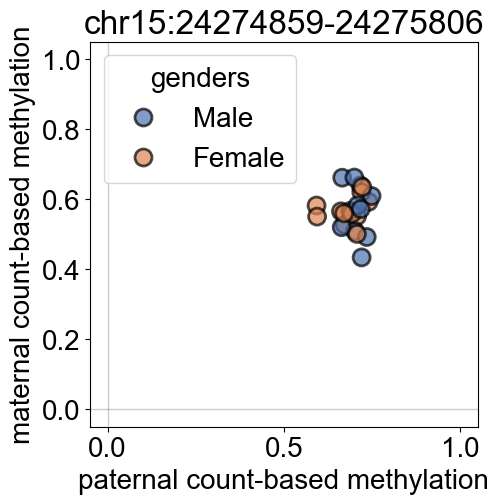

0.78 0.69 E G NA12877 chr15:25059478-25100741 Male 74
0.77 0.69 I K NA12878 chr15:25059478-25100741 Female 73
0.76 0.68 G I NA12887 chr15:25059478-25100741 Female 39
0.76 0.69 G I NA12885 chr15:25059478-25100741 Female 43
0.79 0.71 G I NA12883 chr15:25059478-25100741 Male 46
0.75 0.69 E I NA12881 chr15:25059478-25100741 Female 50
0.78 0.66 G K NA12879 chr15:25059478-25100741 Female 53
0.81 0.71 G K NA12886 chr15:25059478-25100741 Male 41
0.79 0.72 E I NA12884 chr15:25059478-25100741 Male 44
0.77 0.73 G I NA12882 chr15:25059478-25100741 Male 47
0.78 0.68 B G 200081 chr15:25059478-25100741 Female 50
0.79 0.68 B G 200082 chr15:25059478-25100741 Female 48
0.76 0.68 A K 200084 chr15:25059478-25100741 Male 46
0.77 0.68 A K 200085 chr15:25059478-25100741 Male 43
0.78 0.67 A K 200086 chr15:25059478-25100741 Female 41
0.77 0.66 B G 200087 chr15:25059478-25100741 Male 38
0.75 0.67 G C 200101 chr15:25059478-25100741 Male 37
0.76 0.65 K C 200102 chr15:25059478-25100741 Male 35
0.76 0.70 K D 200103

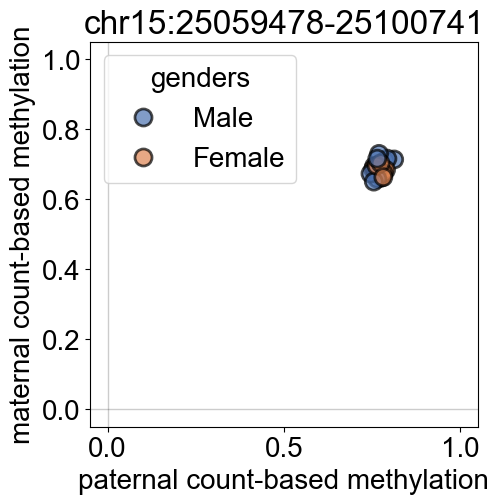

0.69 0.65 I K NA12878 chr15:23829311-23829706 Female 73
0.72 0.63 G I NA12887 chr15:23829311-23829706 Female 39
0.66 0.65 G I NA12885 chr15:23829311-23829706 Female 43
0.71 0.70 G I NA12883 chr15:23829311-23829706 Male 46
0.63 0.68 E I NA12881 chr15:23829311-23829706 Female 50
0.75 0.67 G K NA12879 chr15:23829311-23829706 Female 53
0.63 0.58 G K NA12886 chr15:23829311-23829706 Male 41
0.69 0.63 E I NA12884 chr15:23829311-23829706 Male 44
0.75 0.65 G I NA12882 chr15:23829311-23829706 Male 47
0.77 0.61 B G 200081 chr15:23829311-23829706 Female 50
0.72 0.64 B G 200082 chr15:23829311-23829706 Female 48
0.74 0.61 A K 200084 chr15:23829311-23829706 Male 46
0.74 0.65 A K 200085 chr15:23829311-23829706 Male 43
0.65 0.62 B G 200087 chr15:23829311-23829706 Male 38
0.71 0.61 G C 200101 chr15:23829311-23829706 Male 37
0.72 0.69 K C 200102 chr15:23829311-23829706 Male 35
0.71 0.66 G D 200104 chr15:23829311-23829706 Female 29
0.72 0.64 G C 200106 chr15:23829311-23829706 Female 24


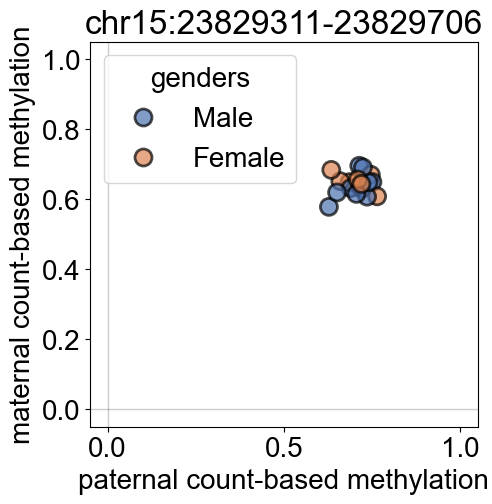

0.61 0.83 E G NA12877 chr4:6104931-6106089 Male 74
0.46 0.71 I K NA12878 chr4:6104931-6106089 Female 73
0.51 0.91 G K NA12887 chr4:6104931-6106089 Female 39
0.58 0.84 E I NA12885 chr4:6104931-6106089 Female 43
0.50 0.81 E I NA12883 chr4:6104931-6106089 Male 46
0.53 0.87 G I NA12881 chr4:6104931-6106089 Female 50
0.57 0.84 E I NA12879 chr4:6104931-6106089 Female 53
0.53 0.83 G I NA12884 chr4:6104931-6106089 Male 44
0.51 0.89 E K NA12882 chr4:6104931-6106089 Male 47
0.42 0.50 B E 200081 chr4:6104931-6106089 Female 50
0.44 0.84 A E 200082 chr4:6104931-6106089 Female 48
0.48 0.88 B E 200084 chr4:6104931-6106089 Male 46
0.48 0.87 B E 200086 chr4:6104931-6106089 Female 41
0.46 0.87 B I 200087 chr4:6104931-6106089 Male 38
0.56 0.87 G D 200101 chr4:6104931-6106089 Male 37
0.53 0.85 I C 200103 chr4:6104931-6106089 Female 33
0.54 0.89 I C 200105 chr4:6104931-6106089 Male 26
0.40 0.89 I C 200106 chr4:6104931-6106089 Female 24


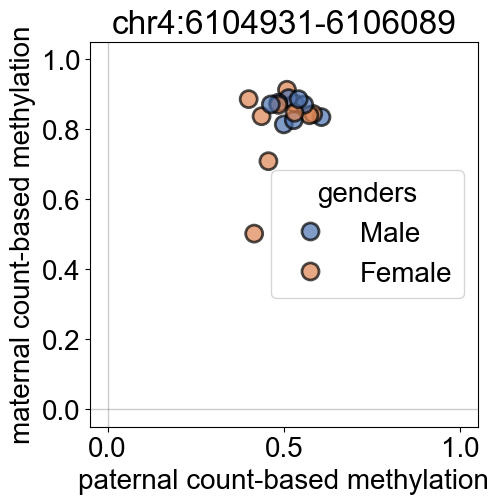

0.33 0.56 I K NA12878 chr15:23877454-23878654 Female 73
0.33 0.46 G I NA12887 chr15:23877454-23878654 Female 39
0.31 0.54 G I NA12885 chr15:23877454-23878654 Female 43
0.31 0.48 G I NA12883 chr15:23877454-23878654 Male 46
0.31 0.50 E I NA12881 chr15:23877454-23878654 Female 50
0.28 0.46 G K NA12879 chr15:23877454-23878654 Female 53
0.35 0.60 G K NA12886 chr15:23877454-23878654 Male 41
0.31 0.62 E I NA12884 chr15:23877454-23878654 Male 44
0.34 0.54 G I NA12882 chr15:23877454-23878654 Male 47
0.29 0.54 B G 200081 chr15:23877454-23878654 Female 50
0.34 0.54 B G 200082 chr15:23877454-23878654 Female 48
0.33 0.56 A K 200084 chr15:23877454-23878654 Male 46
0.34 0.50 A K 200085 chr15:23877454-23878654 Male 43
0.33 0.54 A K 200086 chr15:23877454-23878654 Female 41
0.32 0.54 G C 200101 chr15:23877454-23878654 Male 37
0.34 0.54 K C 200102 chr15:23877454-23878654 Male 35
0.33 0.50 K D 200103 chr15:23877454-23878654 Female 33
0.30 0.48 G D 200104 chr15:23877454-23878654 Female 29
0.38 0.52 K D 200

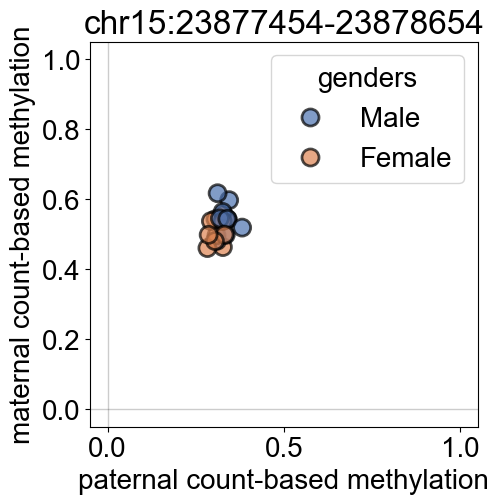

In [60]:
def plot_mat_vs_pat_meth(loci_meth_bed, mode, hue): 
    df_loci = read_dataframe_from_bed(loci_meth_bed)
    df_loci = df_loci.sample(8, seed=42)

    df_samples = get_sampleid_generation_gender_age_methylation()

    for locus in df_loci.iter_rows(named=True):
        chrom, start, end = locus['chrom'], locus['start'], locus['end']
        coordinate = f"{chrom}:{start}-{end}"
        meths_pat, meths_mat, haps_pat, haps_mat, sample_ids_with_meth, genders, ages = [], [], [], [], [], [], []
        for sample in df_samples.iter_rows(named=True):
            id, gender, age = sample['id'], sample['gender'], sample['age_at_blood_draw']
            try:
                meths_pat.append(locus[f'{id}_{mode}_based_meth_pat'])
                meths_mat.append(locus[f'{id}_{mode}_based_meth_mat'])
                haps_pat.append(locus[f'{id}_founder_pat'])
                haps_mat.append(locus[f'{id}_founder_mat'])
                sample_ids_with_meth.append(id)
                genders.append(gender)
                ages.append(age)
            except KeyError: 
                continue

        for meth_pat, meth_mat, hap_pat, hap_mat, sample_id, gender, age in zip(
            meths_pat, meths_mat, haps_pat, haps_mat, sample_ids_with_meth, genders, ages
        ): 
            if meth_pat is not None and meth_mat is not None: 
                print(f"{meth_pat:.2f}", f"{meth_mat:.2f}", hap_pat, hap_mat, sample_id, coordinate, gender, age)

        df = pl.DataFrame({
            'meths_pat': meths_pat,
            'meths_mat': meths_mat, 
            'genders': genders, 
            'ages': ages
        })
    
        if hue == 'ages': 
            palette = 'viridis'
        elif hue == 'genders': 
            palette = 'deep'
        else: 
            raise ValueError(hue)
        
        plt.figure(figsize=(5,5))
        sns.scatterplot(
            data=df, 
            x="meths_pat", 
            y="meths_mat", 
            hue=hue,
            palette=palette,
            s=150,          
            marker='o',     
            edgecolor='black', 
            linewidths=2,   
            alpha=0.7
        )
        plt.title(coordinate)
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.2)
        plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.2)
        plt.xlabel(f'paternal {mode}-based methylation')
        plt.ylabel(f'maternal {mode}-based methylation')
        plt.show()
        
plot_mat_vs_pat_meth(
    loci_meth_bed='/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-truth-unique.akbari.meth.bed',
    mode='count',
    hue='genders'
)

### Compute methylation at loci common to candidate and truth sets

```
compute-methylation-loci \
    --loci-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-common.akbari.bed \
    --sample-meth-beds /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/all-cpgs.all-samples.tsv \
    --loci-meth-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-common.akbari.meth.bed
```

### Visualize haplotype-specific methylation at a random subset of loci common to candidate and truth sets

0.24 0.85 E G NA12877 chr19:56838000-56839000 Male 74
0.25 0.82 I K NA12878 chr19:56838000-56839000 Female 73
0.24 0.75 E K NA12887 chr19:56838000-56839000 Female 39
0.23 0.85 G I NA12885 chr19:56838000-56839000 Female 43
0.20 0.85 G I NA12883 chr19:56838000-56839000 Male 46
0.22 0.81 G K NA12881 chr19:56838000-56839000 Female 50
0.19 0.78 E I NA12879 chr19:56838000-56839000 Female 53
0.24 0.82 E K NA12886 chr19:56838000-56839000 Male 41
0.21 0.87 G I NA12884 chr19:56838000-56839000 Male 44
0.22 0.80 G K NA12882 chr19:56838000-56839000 Male 47
0.24 0.82 A I 200081 chr19:56838000-56839000 Female 50
0.28 0.79 A I 200082 chr19:56838000-56839000 Female 48
0.22 0.81 B I 200084 chr19:56838000-56839000 Male 46
0.23 0.79 A I 200085 chr19:56838000-56839000 Male 43
0.19 0.80 B I 200086 chr19:56838000-56839000 Female 41
0.22 0.82 E D 200101 chr19:56838000-56839000 Male 37
0.27 0.80 E C 200102 chr19:56838000-56839000 Male 35
0.22 0.80 K D 200103 chr19:56838000-56839000 Female 33
0.24 0.81 K C 2001

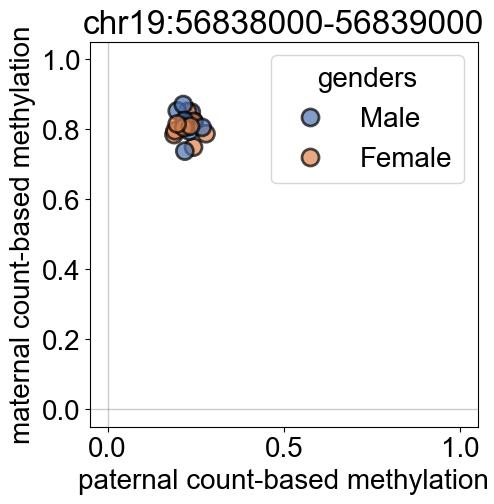

0.19 0.89 E G NA12877 chr7:130492000-130493000 Male 74
0.18 0.88 I K NA12878 chr7:130492000-130493000 Female 73
0.23 0.90 E I NA12885 chr7:130492000-130493000 Female 43
0.24 0.90 E I NA12883 chr7:130492000-130493000 Male 46
0.24 0.87 E I NA12879 chr7:130492000-130493000 Female 53
0.20 0.89 E I NA12884 chr7:130492000-130493000 Male 44
0.21 0.89 G K NA12882 chr7:130492000-130493000 Male 47
0.24 0.90 A I 200081 chr7:130492000-130493000 Female 50
0.28 0.69 B E 200084 chr7:130492000-130493000 Male 46
0.21 0.89 A I 200085 chr7:130492000-130493000 Male 43
0.35 0.80 B E 200086 chr7:130492000-130493000 Female 41
0.34 0.66 B E 200087 chr7:130492000-130493000 Male 38
0.28 0.85 K C 200102 chr7:130492000-130493000 Male 35
0.18 0.89 K D 200103 chr7:130492000-130493000 Female 33
0.24 0.91 E D 200104 chr7:130492000-130493000 Female 29
0.29 0.91 K D 200105 chr7:130492000-130493000 Male 26


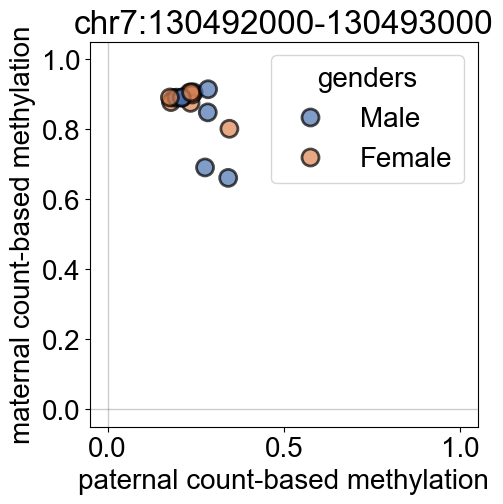

0.20 0.67 E G NA12877 chr20:58852000-58853000 Male 74
0.20 0.63 I K NA12878 chr20:58852000-58853000 Female 73
0.24 0.77 E I NA12887 chr20:58852000-58853000 Female 39
0.23 0.69 G I NA12885 chr20:58852000-58853000 Female 43
0.26 0.70 E K NA12883 chr20:58852000-58853000 Male 46
0.32 0.52 G I NA12882 chr20:58852000-58853000 Male 47
0.23 0.67 A G 200081 chr20:58852000-58853000 Female 50
0.31 0.77 A G 200082 chr20:58852000-58853000 Female 48
0.67 0.26 B G 200084 chr20:58852000-58853000 Male 46
0.23 0.70 A G 200085 chr20:58852000-58853000 Male 43
0.26 0.68 B I 200086 chr20:58852000-58853000 Female 41
0.26 0.68 A I 200087 chr20:58852000-58853000 Male 38
0.28 0.65 E D 200101 chr20:58852000-58853000 Male 37
0.29 0.77 I C 200102 chr20:58852000-58853000 Male 35
0.25 0.73 E C 200103 chr20:58852000-58853000 Female 33
0.24 0.59 E C 200104 chr20:58852000-58853000 Female 29
0.29 0.84 E C 200105 chr20:58852000-58853000 Male 26
0.24 0.83 E D 200106 chr20:58852000-58853000 Female 24


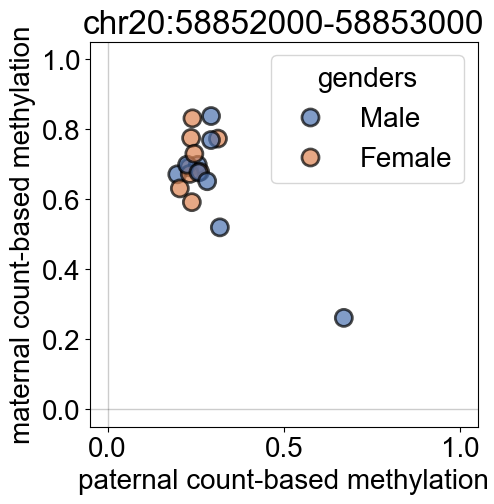

0.57 0.59 E G NA12877 chr19:21082000-21083000 Male 74
0.21 0.82 I K NA12878 chr19:21082000-21083000 Female 73
0.49 0.51 E I NA12887 chr19:21082000-21083000 Female 39
0.46 0.31 E I NA12885 chr19:21082000-21083000 Female 43
0.28 0.82 G K NA12883 chr19:21082000-21083000 Male 46
0.21 0.32 E K NA12879 chr19:21082000-21083000 Female 53
0.24 0.40 G K NA12886 chr19:21082000-21083000 Male 41
0.29 0.87 G K NA12884 chr19:21082000-21083000 Male 44
0.37 0.52 G K NA12882 chr19:21082000-21083000 Male 47
0.20 0.20 A K 200081 chr19:21082000-21083000 Female 50
0.20 0.25 A K 200082 chr19:21082000-21083000 Female 48
0.34 0.81 A K 200084 chr19:21082000-21083000 Male 46
0.23 0.42 B E 200085 chr19:21082000-21083000 Male 43
0.46 0.72 B K 200086 chr19:21082000-21083000 Female 41
0.35 0.87 B E 200087 chr19:21082000-21083000 Male 38
0.53 0.84 K D 200101 chr19:21082000-21083000 Male 37
0.27 0.84 K D 200102 chr19:21082000-21083000 Male 35
0.36 0.18 K D 200103 chr19:21082000-21083000 Female 33
0.52 0.88 G C 200105 

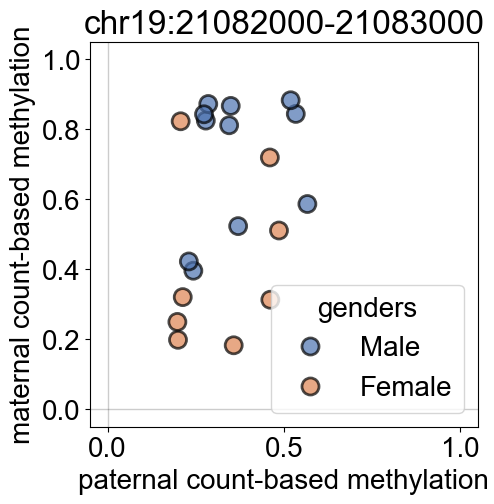

0.26 0.88 E G NA12877 chr19:56840000-56841000 Male 74
0.29 0.87 I K NA12878 chr19:56840000-56841000 Female 73
0.25 0.82 E K NA12887 chr19:56840000-56841000 Female 39
0.24 0.89 G I NA12885 chr19:56840000-56841000 Female 43
0.28 0.86 G I NA12883 chr19:56840000-56841000 Male 46
0.24 0.86 G K NA12881 chr19:56840000-56841000 Female 50
0.27 0.85 E I NA12879 chr19:56840000-56841000 Female 53
0.31 0.86 E K NA12886 chr19:56840000-56841000 Male 41
0.24 0.86 G I NA12884 chr19:56840000-56841000 Male 44
0.27 0.84 G K NA12882 chr19:56840000-56841000 Male 47
0.25 0.89 A I 200081 chr19:56840000-56841000 Female 50
0.27 0.89 A I 200082 chr19:56840000-56841000 Female 48
0.23 0.89 B I 200084 chr19:56840000-56841000 Male 46
0.24 0.88 A I 200085 chr19:56840000-56841000 Male 43
0.22 0.88 B I 200086 chr19:56840000-56841000 Female 41
0.25 0.88 E D 200101 chr19:56840000-56841000 Male 37
0.27 0.90 E C 200102 chr19:56840000-56841000 Male 35
0.26 0.90 K D 200103 chr19:56840000-56841000 Female 33
0.27 0.88 K C 2001

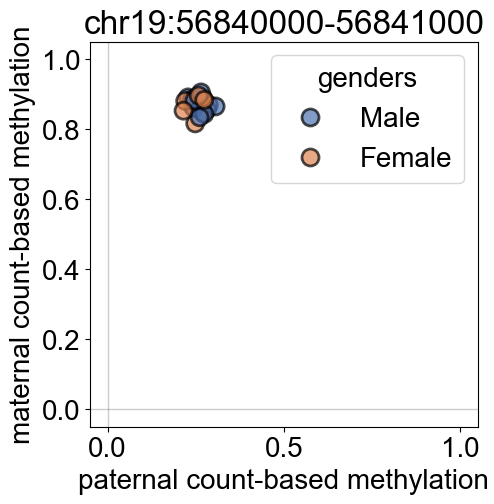

0.26 0.83 E G NA12877 chr15:98865000-98866000 Male 74
0.31 0.77 I K NA12878 chr15:98865000-98866000 Female 73
0.47 0.76 E K NA12887 chr15:98865000-98866000 Female 39
0.43 0.83 E K NA12885 chr15:98865000-98866000 Female 43
0.46 0.81 G K NA12883 chr15:98865000-98866000 Male 46
0.46 0.76 E I NA12881 chr15:98865000-98866000 Female 50
0.30 0.75 E I NA12879 chr15:98865000-98866000 Female 53
0.25 0.87 E K NA12884 chr15:98865000-98866000 Male 44
0.64 0.82 A I 200081 chr15:98865000-98866000 Female 50
0.20 0.82 B E 200082 chr15:98865000-98866000 Female 48
0.29 0.83 B E 200084 chr15:98865000-98866000 Male 46
0.23 0.82 B I 200085 chr15:98865000-98866000 Male 43
0.52 0.84 B E 200086 chr15:98865000-98866000 Female 41
0.20 0.82 B E 200087 chr15:98865000-98866000 Male 38
0.33 0.87 I D 200101 chr15:98865000-98866000 Male 37
0.25 0.83 G D 200102 chr15:98865000-98866000 Male 35
0.27 0.83 I D 200103 chr15:98865000-98866000 Female 33
0.29 0.80 I C 200104 chr15:98865000-98866000 Female 29
0.19 0.82 I D 2001

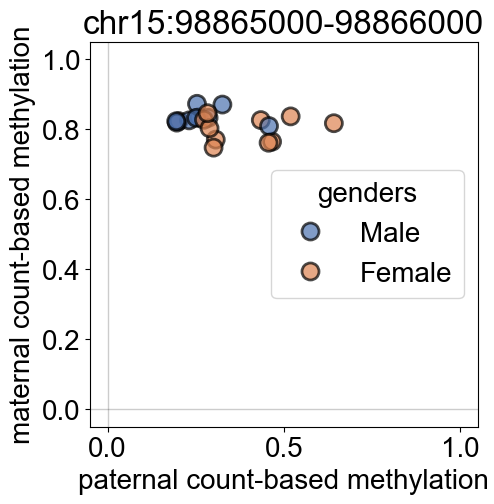

0.75 0.25 E G NA12877 chr2:206267000-206268000 Male 74
0.74 0.24 I K NA12878 chr2:206267000-206268000 Female 73
0.82 0.29 E I NA12887 chr2:206267000-206268000 Female 39
0.76 0.29 E K NA12885 chr2:206267000-206268000 Female 43
0.78 0.34 E I NA12883 chr2:206267000-206268000 Male 46
0.80 0.26 G I NA12881 chr2:206267000-206268000 Female 50
0.77 0.26 E I NA12879 chr2:206267000-206268000 Female 53
0.79 0.36 G K NA12886 chr2:206267000-206268000 Male 41
0.82 0.31 E I NA12884 chr2:206267000-206268000 Male 44
0.76 0.24 E I NA12882 chr2:206267000-206268000 Male 47
0.80 0.37 A I 200081 chr2:206267000-206268000 Female 50
0.83 0.32 A E 200082 chr2:206267000-206268000 Female 48
0.77 0.32 A I 200084 chr2:206267000-206268000 Male 46
0.81 0.23 B I 200085 chr2:206267000-206268000 Male 43
0.81 0.30 A E 200086 chr2:206267000-206268000 Female 41
0.72 0.29 B I 200087 chr2:206267000-206268000 Male 38
0.80 0.28 K C 200101 chr2:206267000-206268000 Male 37
0.80 0.31 G C 200102 chr2:206267000-206268000 Male 35
0.

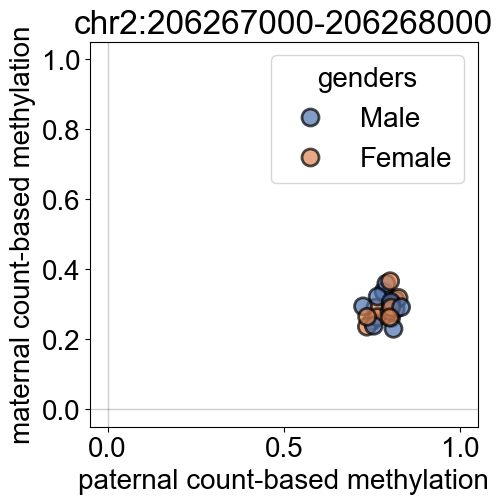

0.76 0.19 E G NA12877 chr16:3443000-3444000 Male 74
0.81 0.18 I K NA12878 chr16:3443000-3444000 Female 73
0.79 0.17 G K NA12885 chr16:3443000-3444000 Female 43
0.82 0.33 G K NA12883 chr16:3443000-3444000 Male 46
0.85 0.18 E I NA12881 chr16:3443000-3444000 Female 50
0.80 0.15 E K NA12884 chr16:3443000-3444000 Male 44
0.81 0.17 G K NA12882 chr16:3443000-3444000 Male 47
0.77 0.19 B G 200081 chr16:3443000-3444000 Female 50
0.77 0.18 A I 200084 chr16:3443000-3444000 Male 46
0.81 0.17 A G 200085 chr16:3443000-3444000 Male 43
0.78 0.18 A I 200087 chr16:3443000-3444000 Male 38
0.83 0.14 E C 200101 chr16:3443000-3444000 Male 37
0.80 0.20 E C 200102 chr16:3443000-3444000 Male 35
0.80 0.16 K C 200103 chr16:3443000-3444000 Female 33
0.75 0.15 E C 200104 chr16:3443000-3444000 Female 29
0.85 0.19 E C 200105 chr16:3443000-3444000 Male 26
0.78 0.20 E D 200106 chr16:3443000-3444000 Female 24


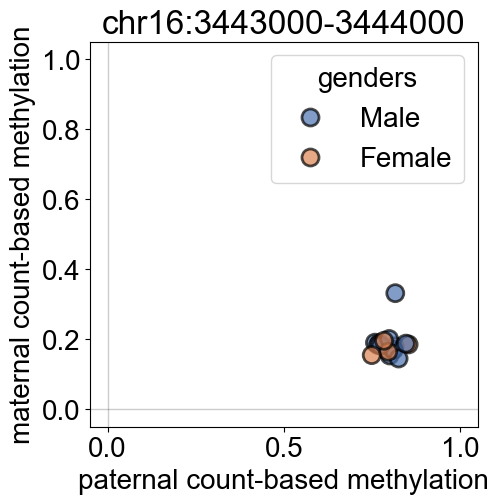

In [61]:
plot_mat_vs_pat_meth(
    loci_meth_bed='/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-common.akbari.meth.bed',
    mode='count',
    hue='genders'
)

### Compute methylation at loci in candidate-unique sets

```
compute-methylation-loci \
    --loci-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidate-unique.akbari.bed \
    --sample-meth-beds /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/all-cpgs.all-samples.tsv \
    --loci-meth-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidate-unique.akbari.meth.bed
```

### Visualize haplotype-specific methylation at a random subset of loci in candidate-unique sets

0.55 0.34 G K NA12887 chrX:151397000-151398000 Female 39
0.77 0.18 G K NA12885 chrX:151397000-151398000 Female 43
0.29 0.46 G K NA12879 chrX:151397000-151398000 Female 53
0.19 0.80 A K 200081 chrX:151397000-151398000 Female 50
0.70 0.26 A G 200082 chrX:151397000-151398000 Female 48
0.40 0.51 A G 200086 chrX:151397000-151398000 Female 41
0.36 0.54 I C 200103 chrX:151397000-151398000 Female 33
0.32 0.43 I C 200104 chrX:151397000-151398000 Female 29
0.48 0.45 I C 200106 chrX:151397000-151398000 Female 24


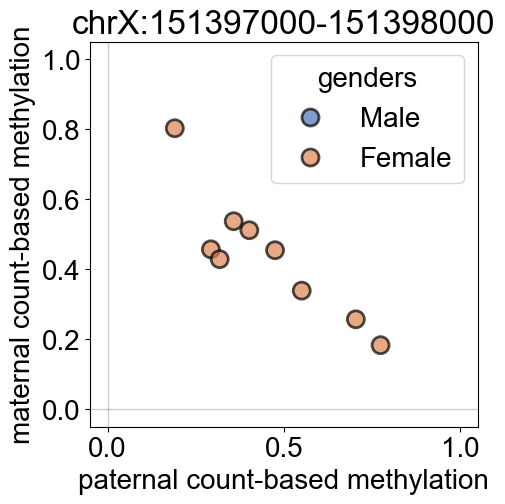

0.43 0.41 E G NA12877 chr10:130301000-130302000 Male 74
0.41 0.53 I K NA12878 chr10:130301000-130302000 Female 73
0.67 0.41 E I NA12885 chr10:130301000-130302000 Female 43
0.36 0.51 E K NA12883 chr10:130301000-130302000 Male 46
0.72 0.55 G K NA12881 chr10:130301000-130302000 Female 50
0.49 0.38 E I NA12879 chr10:130301000-130302000 Female 53
0.61 0.41 G I NA12886 chr10:130301000-130302000 Male 41
0.37 0.46 E K NA12884 chr10:130301000-130302000 Male 44
0.41 0.45 E K NA12882 chr10:130301000-130302000 Male 47
0.59 0.56 A I 200081 chr10:130301000-130302000 Female 50
0.36 0.49 A E 200082 chr10:130301000-130302000 Female 48
0.51 0.33 A I 200084 chr10:130301000-130302000 Male 46
0.42 0.32 A E 200085 chr10:130301000-130302000 Male 43
0.77 0.41 B I 200086 chr10:130301000-130302000 Female 41
0.35 0.86 I D 200101 chr10:130301000-130302000 Male 37
0.28 0.86 I D 200102 chr10:130301000-130302000 Male 35
0.43 0.50 G C 200103 chr10:130301000-130302000 Female 33
0.65 0.60 G C 200104 chr10:130301000-130

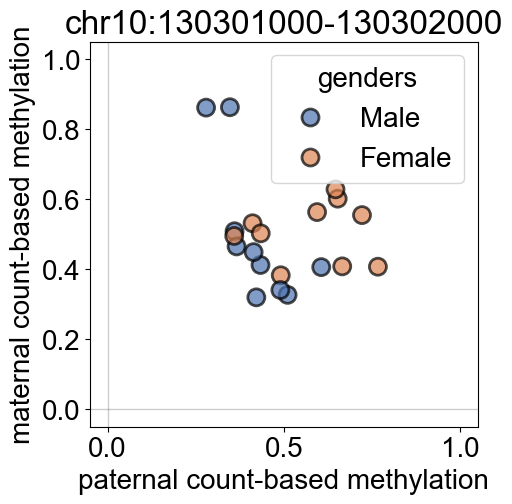

0.42 0.56 I K NA12878 chrX:149541000-149542000 Female 73
0.74 0.24 G K NA12885 chrX:149541000-149542000 Female 43
0.17 0.80 A K 200081 chrX:149541000-149542000 Female 50
0.60 0.34 A G 200082 chrX:149541000-149542000 Female 48
0.50 0.45 A G 200086 chrX:149541000-149542000 Female 41
0.37 0.54 I C 200103 chrX:149541000-149542000 Female 33
0.47 0.67 I C 200104 chrX:149541000-149542000 Female 29


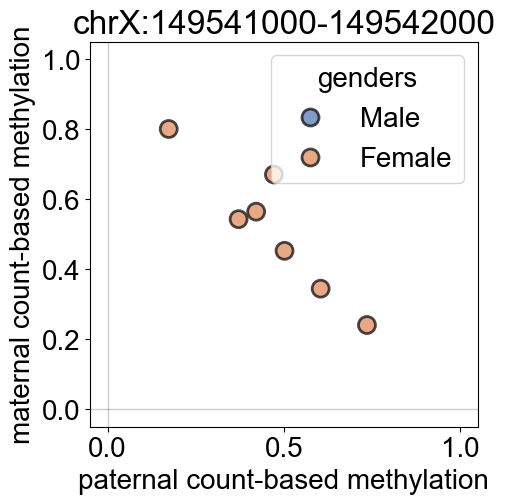

0.45 0.67 G K NA12887 chrX:50474000-50475000 Female 39
0.36 0.66 G I NA12885 chrX:50474000-50475000 Female 43
0.43 0.62 G I NA12881 chrX:50474000-50475000 Female 50
0.43 0.50 G K NA12879 chrX:50474000-50475000 Female 53
0.76 0.29 A K 200081 chrX:50474000-50475000 Female 50
0.38 0.46 A G 200082 chrX:50474000-50475000 Female 48
0.53 0.57 A G 200086 chrX:50474000-50475000 Female 41
0.47 0.44 I D 200103 chrX:50474000-50475000 Female 33
0.55 0.52 I C 200104 chrX:50474000-50475000 Female 29
0.54 0.44 I C 200106 chrX:50474000-50475000 Female 24


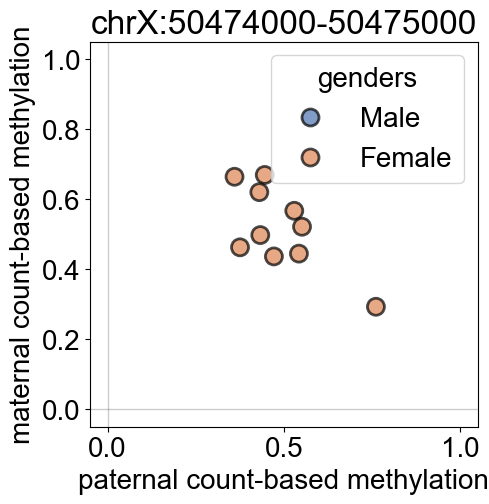

0.32 0.56 I K NA12878 chrX:77900000-77901000 Female 73
0.62 0.21 G K NA12887 chrX:77900000-77901000 Female 39
0.21 0.77 A K 200081 chrX:77900000-77901000 Female 50
0.70 0.24 A G 200082 chrX:77900000-77901000 Female 48
0.35 0.51 I C 200106 chrX:77900000-77901000 Female 24


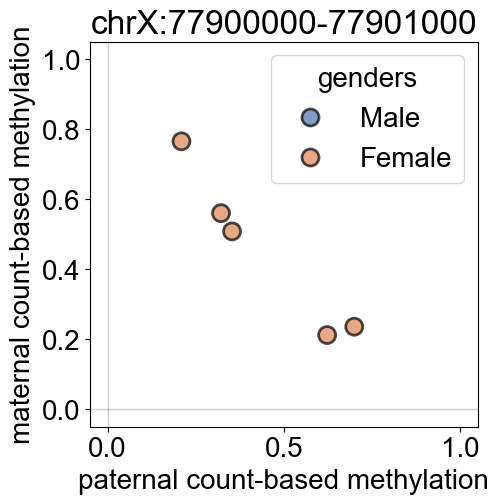

0.37 0.57 I K NA12878 chrX:45769000-45770000 Female 73
0.60 0.24 G I NA12885 chrX:45769000-45770000 Female 43
0.62 0.32 G I NA12881 chrX:45769000-45770000 Female 50
0.28 0.71 A K 200081 chrX:45769000-45770000 Female 50
0.57 0.29 A G 200082 chrX:45769000-45770000 Female 48
0.48 0.39 A G 200086 chrX:45769000-45770000 Female 41
0.36 0.38 I D 200103 chrX:45769000-45770000 Female 33
0.35 0.49 I D 200104 chrX:45769000-45770000 Female 29
0.54 0.44 I C 200106 chrX:45769000-45770000 Female 24


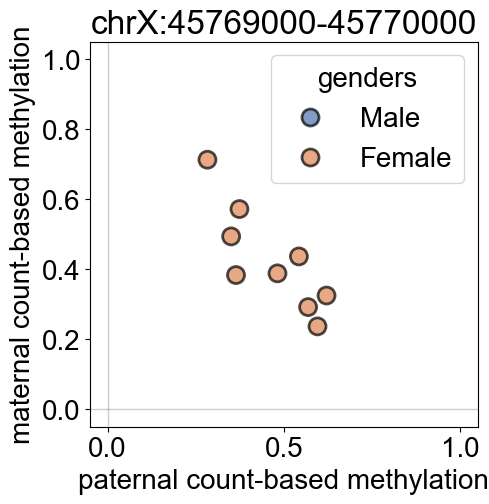

0.32 0.22 E G NA12877 chr4:19520000-19521000 Male 74
0.01 0.67 G K NA12887 chr4:19520000-19521000 Female 39
0.02 0.70 E I NA12885 chr4:19520000-19521000 Female 43
0.02 0.62 E I NA12883 chr4:19520000-19521000 Male 46
0.01 0.62 G I NA12881 chr4:19520000-19521000 Female 50
0.02 0.65 E I NA12879 chr4:19520000-19521000 Female 53
0.02 0.64 G I NA12886 chr4:19520000-19521000 Male 41
0.01 0.67 G I NA12884 chr4:19520000-19521000 Male 44
0.01 0.71 E K NA12882 chr4:19520000-19521000 Male 47
0.60 0.80 A E 200082 chr4:19520000-19521000 Female 48
0.55 0.73 B E 200084 chr4:19520000-19521000 Male 46
0.02 0.62 A I 200085 chr4:19520000-19521000 Male 43
0.01 0.69 B I 200087 chr4:19520000-19521000 Male 38
0.04 0.72 G D 200101 chr4:19520000-19521000 Male 37
0.62 0.39 I D 200102 chr4:19520000-19521000 Male 35
0.64 0.01 I C 200103 chr4:19520000-19521000 Female 33
0.04 0.73 G D 200104 chr4:19520000-19521000 Female 29
0.52 0.35 I D 200105 chr4:19520000-19521000 Male 26
0.70 0.02 I C 200106 chr4:19520000-195210

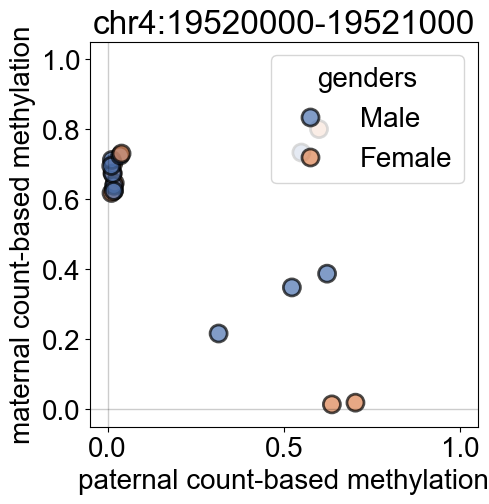

0.48 0.74 I K NA12878 chrX:48676000-48677000 Female 73
0.54 0.30 G K NA12887 chrX:48676000-48677000 Female 39
0.75 0.19 G I NA12885 chrX:48676000-48677000 Female 43
0.48 0.40 G I NA12881 chrX:48676000-48677000 Female 50
0.22 0.79 A K 200081 chrX:48676000-48677000 Female 50
0.66 0.31 A G 200082 chrX:48676000-48677000 Female 48


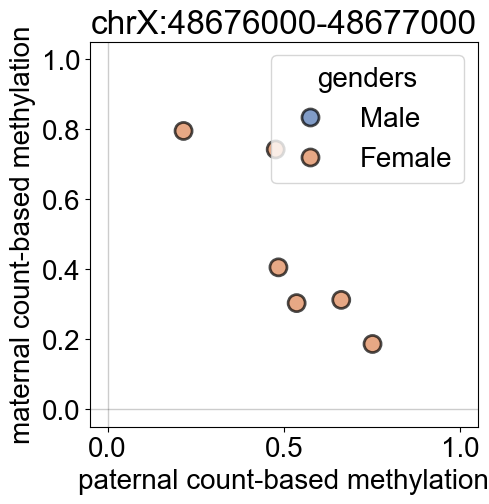

In [62]:
plot_mat_vs_pat_meth(
    loci_meth_bed='/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidate-unique.akbari.meth.bed',
    mode='count',
    hue='genders'
)